# Problem Statement

The objective is to take a noisy handwritten digit image and reconstruct the original clean image.

# 1.Import Necessary Libraries

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    UpSampling2D
)
from tensorflow.keras.optimizers import Adam

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


# 2.Import Dataset

In [46]:
(X_train, _), (X_test, _) = mnist.load_data()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (60000, 28, 28)
X_test: (10000, 28, 28)


In [45]:
X_train.shape,X_test.shape

((60000, 28, 28), (10000, 28, 28))

# 3.Data Preparation

## 3.1. Add the Channel

In [4]:
X_train = X_train.reshape(60000, 28, 28,1)
X_test=X_test.reshape(10000, 28, 28,1)

In [5]:
X_train.shape,X_test.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

## 3.2...Normalizing

In [47]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [48]:
print("Train min:", X_train.min())
print("Train max:", X_train.max())

print("Test min:", X_test.min())
print("Test max:", X_test.max())

Train min: 0.0
Train max: 1.0
Test min: 0.0
Test max: 1.0


In [49]:
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

In [50]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (60000, 28, 28, 1)
X_test: (10000, 28, 28, 1)


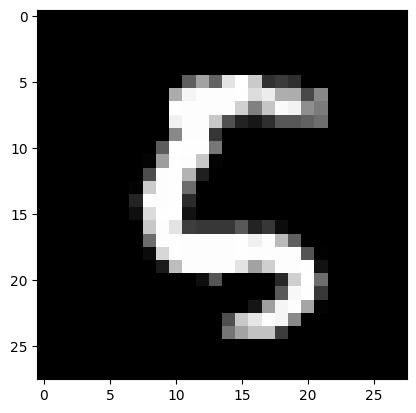

In [7]:
plt.imshow(X_train[2000],cmap="grey")

## 3.3. Add Noise

In [51]:
noise_factor = 0.30

noise_train = np.random.normal(
    loc=0.0,
    scale=1.0,
    size=X_train.shape
).astype("float32")

noise_test = np.random.normal(
    loc=0.0,
    scale=1.0,
    size=X_test.shape
).astype("float32")

X_train_noisy = X_train + noise_factor * noise_train
X_test_noisy = X_test + noise_factor * noise_test

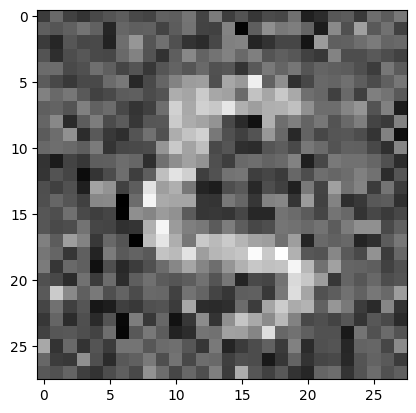

In [52]:
plt.imshow(X_train_noise[2000],cmap="grey")

In [10]:
X_train_noise.max(),X_test_noise.min()

(np.float64(2.468391433585296), np.float64(-1.6133114228137926))

## 3.4. Add the Clip

In [53]:
X_train_noisy = np.clip(X_train_noisy, 0.0, 1.0)
X_test_noisy = np.clip(X_test_noisy, 0.0, 1.0)

In [54]:
print("Noisy train min:", X_train_noisy.min())
print("Noisy train max:", X_train_noisy.max())

print("Noisy test min:", X_test_noisy.min())
print("Noisy test max:", X_test_noisy.max())

Noisy train min: 0.0
Noisy train max: 1.0
Noisy test min: 0.0
Noisy test max: 1.0


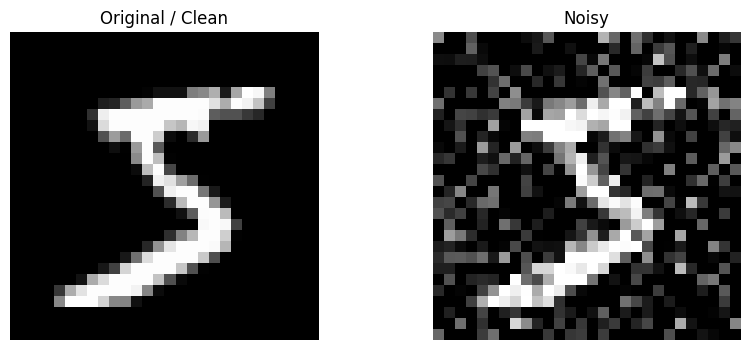

In [55]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(X_train[0].squeeze(), cmap="gray")
plt.title("Original / Clean")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(X_train_noisy[0].squeeze(), cmap="gray")
plt.title("Noisy")
plt.axis("off")

plt.show()

# 4.Model Building

In [56]:
model = Sequential()

# =========================
# ENCODER
# =========================

model.add(
    Conv2D(
        filters=32,
        kernel_size=(3, 3),
        padding="same",
        activation="relu",
        input_shape=(28, 28, 1)
    )
)

model.add(
    MaxPooling2D(
        pool_size=(2, 2)
    )
)

model.add(
    Conv2D(
        filters=8,
        kernel_size=(3, 3),
        padding="same",
        activation="relu"
    )
)

model.add(
    MaxPooling2D(
        pool_size=(2, 2)
    )
)


# =========================
# DECODER
# =========================

model.add(
    Conv2D(
        filters=8,
        kernel_size=(3, 3),
        padding="same",
        activation="relu"
    )
)

model.add(
    UpSampling2D(
        size=(2, 2)
    )
)

model.add(
    Conv2D(
        filters=8,
        kernel_size=(3, 3),
        padding="same",
        activation="relu"
    )
)

model.add(
    UpSampling2D(
        size=(2, 2)
    )
)

model.add(
    Conv2D(
        filters=32,
        kernel_size=(3, 3),
        padding="same",
        activation="relu"
    )
)

# =========================
# OUTPUT
# =========================

model.add(
    Conv2D(
        filters=1,
        kernel_size=(3, 3),
        padding="same",
        activation="sigmoid"
    )
)

In [58]:
print("Output shape:", model.output_shape)
print("Final activation:", model.layers[-1].activation.__name__)

Output shape: (None, 28, 28, 1)
Final activation: sigmoid


# 5.Model Compilation

In [62]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["mae"]
)

# 6.Model Training

In [63]:
history = model.fit(
    X_train_noisy,
    X_train,
    batch_size=128,
    epochs=10,
    validation_data=(X_test_noisy, X_test),
    shuffle=True
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 46s 96ms/step - loss: 0.0848 - mae: 0.0283 - val_loss: 0.0837 - val_mae: 0.0278
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 78s 88ms/step - loss: 0.0843 - mae: 0.0280 - val_loss: 0.0838 - val_mae: 0.0277
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 47s 99ms/step - loss: 0.0841 - mae: 0.0278 - val_loss: 0.0835 - val_mae: 0.0275
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 42s 89ms/step - loss: 0.0838 - mae: 0.0276 - val_loss: 0.0832 - val_mae: 0.0272
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 38s 82ms/step - loss: 0.0836 - mae: 0.0274 - val_loss: 0.0827 - val_mae: 0.0269
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 45s 96ms/step - loss: 0.0833 - mae: 0.0272 - val_loss: 0.0827 - val_mae: 0.0270
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 48s 103ms/step - loss: 0.0832 - mae: 0.0271 - val_loss: 0.0829 - val_mae: 0.0269
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 72s 81ms/step - loss: 0.0830 - mae: 0.0270 - val_loss: 0.0823 - val_mae: 0.0268
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━

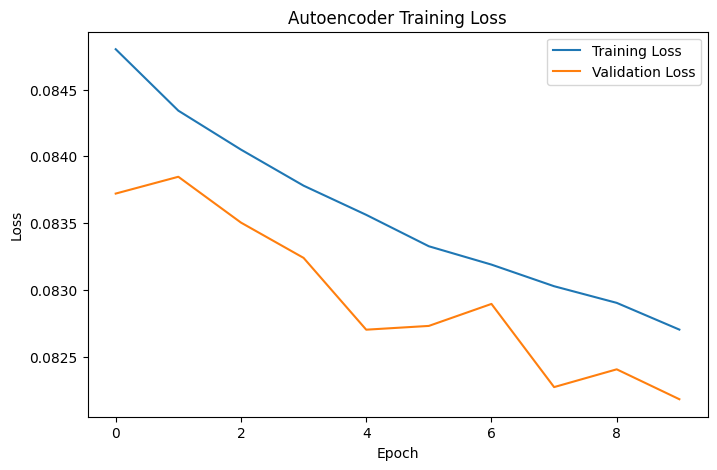

In [64]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Autoencoder Training Loss")
plt.legend()
plt.show()

# 7.Model Prediction

In [65]:
predictions = model.predict(
    X_test_noisy[:10],
    verbose=1
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step


In [66]:
print("Prediction shape:", predictions.shape)
print("Prediction min:", predictions.min())
print("Prediction max:", predictions.max())
print("Prediction mean:", predictions.mean())

Prediction shape: (10, 28, 28, 1)
Prediction min: 9.231376e-12
Prediction max: 0.9972464
Prediction mean: 0.11177186


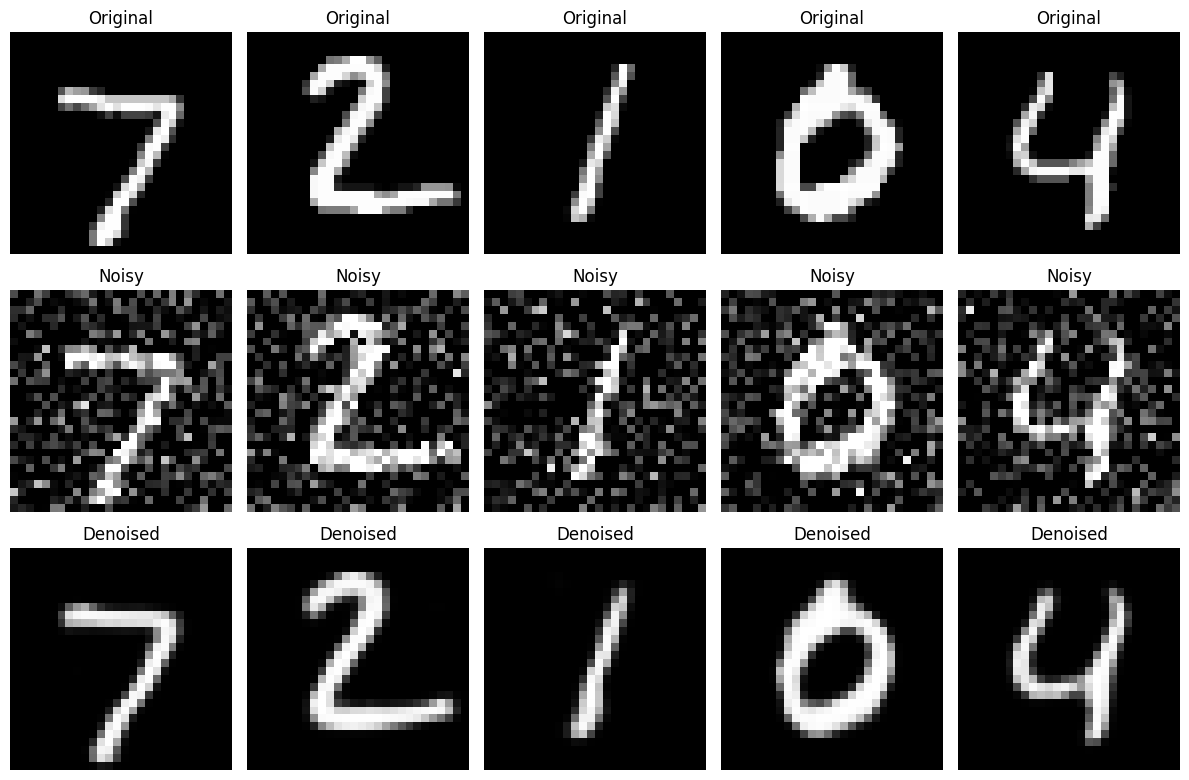

In [67]:
n = 5

plt.figure(figsize=(12, 8))

for i in range(n):

    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(X_test[i].squeeze(), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Noisy
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(X_test_noisy[i].squeeze(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    # Denoised
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(predictions[i].squeeze(), cmap="gray")
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()
plt.show()

# 9.Save the Model

In [69]:
model.save("denoising.h5")

In [70]:
from keras.models import load_model

In [71]:
intelligence_denoise = load_model("denoising.h5")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step


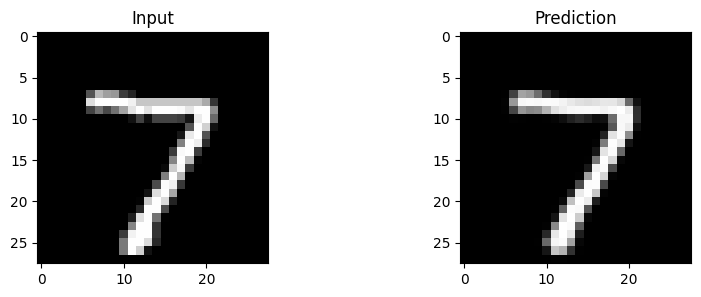

In [72]:
import matplotlib.pyplot as plt

sample = X_test[0:1]

prediction = model.predict(sample)

plt.figure(figsize=(10,3))

plt.subplot(1,2,1)
plt.imshow(sample[0].reshape(28,28), cmap='gray')
plt.title("Input")

plt.subplot(1,2,2)
plt.imshow(prediction[0].reshape(28,28), cmap='gray')
plt.title("Prediction")

plt.show()